# 04 · Deep Learning — PyTorch MLP (Dual Head)
**Project:** Eco-Urbanomics — Vehicle CO2 Emissions  
**Goal:** Train a dual-head MLP that simultaneously classifies High_Emitter and regresses CO2 g/km.  
**Why dual-head:** Shared feature extraction benefits both tasks; regression head acts as an auxiliary signal that regularises the classification head — especially useful when classification is hard.

**Key fixes applied (vs. failed urban dataset run):**
| Problem | Fix |
|---|---|
| Near-zero feature signal | Dataset replaced — fuel consumption correlates r > 0.99 with CO2 |
| Class imbalance (30/70) | `pos_weight = 2.29` in BCEWithLogitsLoss |
| Noisy LR | `ReduceLROnPlateau` scheduler |
| No validation checkpoint | Best model saved by val Macro F1 |
| Overfitting small dataset | Dropout 0.3 + BatchNorm + early stopping |


In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, RocCurveDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path('../data/processed/processed_co2_data.csv')
MODELS    = Path('../models')
OUT_IMG   = Path('../data/outputs')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

df = pd.read_csv(PROCESSED)
TARGET_C = 'High_Emitter'
TARGET_R = 'CO2 Emissions(g/km)'
FEAT_COLS = [c for c in df.columns if c not in [TARGET_C, TARGET_R]]

X  = df[FEAT_COLS].values.astype(np.float32)
yc = df[TARGET_C].values.astype(np.float32)
yr = df[TARGET_R].values.astype(np.float32)

# Normalise regression target to [0,1] range for stable training
yr_min, yr_max = yr.min(), yr.max()
yr_norm = (yr - yr_min) / (yr_max - yr_min)

X_train, X_test, yc_train, yc_test, yr_train, yr_test, yrn_train, yrn_test = train_test_split(
    X, yc, yr, yr_norm, test_size=0.2, random_state=SEED, stratify=yc
)
X_train, X_val, yc_train, yc_val, yr_train, yr_val, yrn_train, yrn_val = train_test_split(
    X_train, yc_train, yr_train, yrn_train,
    test_size=0.15, random_state=SEED, stratify=yc_train
)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")


Device: cuda
Train: (5021, 20) | Val: (887, 20) | Test: (1477, 20)
Features: 20


In [13]:
# ── Dataset ────────────────────────────────────────────────────────────
class CO2Dataset(Dataset):
    def __init__(self, X, yc, yr_norm):
        self.X      = torch.from_numpy(X)
        self.yc     = torch.from_numpy(yc).unsqueeze(1)       # [N,1] for BCE
        self.yr     = torch.from_numpy(yr_norm).unsqueeze(1)  # [N,1] for MSE

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.yc[i], self.yr[i]

BATCH = 64
train_loader = DataLoader(CO2Dataset(X_train, yc_train, yrn_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(CO2Dataset(X_val,   yc_val,   yrn_val),   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(CO2Dataset(X_test,  yc_test,  yrn_test),  batch_size=BATCH, shuffle=False)
print("DataLoaders ready.")


DataLoaders ready.


In [14]:
# ── Dual-Head MLP ──────────────────────────────────────────────────────
class CO2DualHeadMLP(nn.Module):
    """
    Shared trunk → two heads:
      • clf_head  : binary logit  (High Emitter classification)
      • reg_head  : scalar output (normalised CO2 regression)
    """
    def __init__(self, in_dim, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()

        # Shared trunk
        trunk = []
        prev = in_dim
        for h in hidden:
            trunk += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.trunk = nn.Sequential(*trunk)

        # Classification head
        self.clf_head = nn.Sequential(
            nn.Linear(prev, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(prev, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1), nn.Sigmoid()  # output in [0,1] to match normalised target
        )

    def forward(self, x):
        shared = self.trunk(x)
        return self.clf_head(shared), self.reg_head(shared)

model = CO2DualHeadMLP(in_dim=X_train.shape[1]).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


CO2DualHeadMLP(
  (trunk): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (clf_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
  (reg_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace

In [16]:
# ── Loss functions, optimiser, scheduler ──────────────────────────────
n_neg = (yc_train == 0).sum()
n_pos = (yc_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f"pos_weight: {pos_weight.item():.3f}  (neg={n_neg}, pos={n_pos})")

clf_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
reg_criterion = nn.MSELoss()

# Loss weights: tune how much each head contributes to total loss
CLF_WEIGHT = 0.7
REG_WEIGHT = 0.3

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=12
)


pos_weight: 2.290  (neg=3495, pos=1526)


In [17]:
# ── Training loop with early stopping ─────────────────────────────────
def run_epoch(loader, train=True):
    model.train(train)
    total_loss   = 0.0
    all_clf_pred = []
    all_clf_prob = []
    all_clf_true = []
    all_reg_pred = []
    all_reg_true = []

    with torch.set_grad_enabled(train):
        for xb, yc_b, yr_b in loader:
            xb, yc_b, yr_b = xb.to(DEVICE), yc_b.to(DEVICE), yr_b.to(DEVICE)
            clf_logit, reg_out = model(xb)

            loss_clf = clf_criterion(clf_logit, yc_b)
            loss_reg = reg_criterion(reg_out, yr_b)
            loss     = CLF_WEIGHT * loss_clf + REG_WEIGHT * loss_reg

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(xb)
            probs = torch.sigmoid(clf_logit).cpu().detach().numpy().flatten()
            preds = (probs >= 0.5).astype(float)
            all_clf_prob.extend(probs)
            all_clf_pred.extend(preds)
            all_clf_true.extend(yc_b.cpu().numpy().flatten())
            all_reg_pred.extend(reg_out.cpu().detach().numpy().flatten())
            all_reg_true.extend(yr_b.cpu().numpy().flatten())

    n        = len(loader.dataset)
    avg_loss = total_loss / n
    macro_f1 = f1_score(all_clf_true, all_clf_pred, average='macro', zero_division=0)
    rmse     = np.sqrt(mean_squared_error(all_reg_true, all_reg_pred))
    return avg_loss, macro_f1, rmse


EPOCHS        = 200
PATIENCE      = 30
best_val_f1   = 0.0
best_epoch    = 0
epochs_no_imp = 0
history       = {'train_loss':[], 'val_loss':[],
                 'train_f1':[], 'val_f1':[],
                 'train_rmse':[], 'val_rmse':[]}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1, tr_rmse = run_epoch(train_loader, train=True)
    vl_loss, vl_f1, vl_rmse = run_epoch(val_loader,   train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['train_rmse'].append(tr_rmse)
    history['val_rmse'].append(vl_rmse)

    scheduler.step(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1   = vl_f1
        best_epoch    = epoch
        epochs_no_imp = 0
        torch.save(model.state_dict(), MODELS / 'carbon_predictor_nn.pth')
    else:
        epochs_no_imp += 1

    if epoch % 25 == 0 or epoch == 1:
        print(f"Ep {epoch:3d} | "
              f"Train loss {tr_loss:.4f} F1 {tr_f1:.4f} | "
              f"Val loss {vl_loss:.4f} F1 {vl_f1:.4f} | "
              f"LR {optimizer.param_groups[0]['lr']:.2e}")

    if epochs_no_imp >= PATIENCE:
        print(f"\nEarly stop @ epoch {epoch}. Best val F1={best_val_f1:.4f} @ epoch {best_epoch}")
        break

print(f"\nBest checkpoint: epoch {best_epoch}, val Macro F1 = {best_val_f1:.4f}")


Ep   1 | Train loss 0.3812 F1 0.7824 | Val loss 0.1712 F1 0.9207 | LR 1.00e-03
Ep  25 | Train loss 0.1007 F1 0.9497 | Val loss 0.0494 F1 0.9712 | LR 1.00e-03
Ep  50 | Train loss 0.0887 F1 0.9560 | Val loss 0.0422 F1 0.9881 | LR 2.50e-04

Early stop @ epoch 59. Best val F1=0.9907 @ epoch 29

Best checkpoint: epoch 29, val Macro F1 = 0.9907


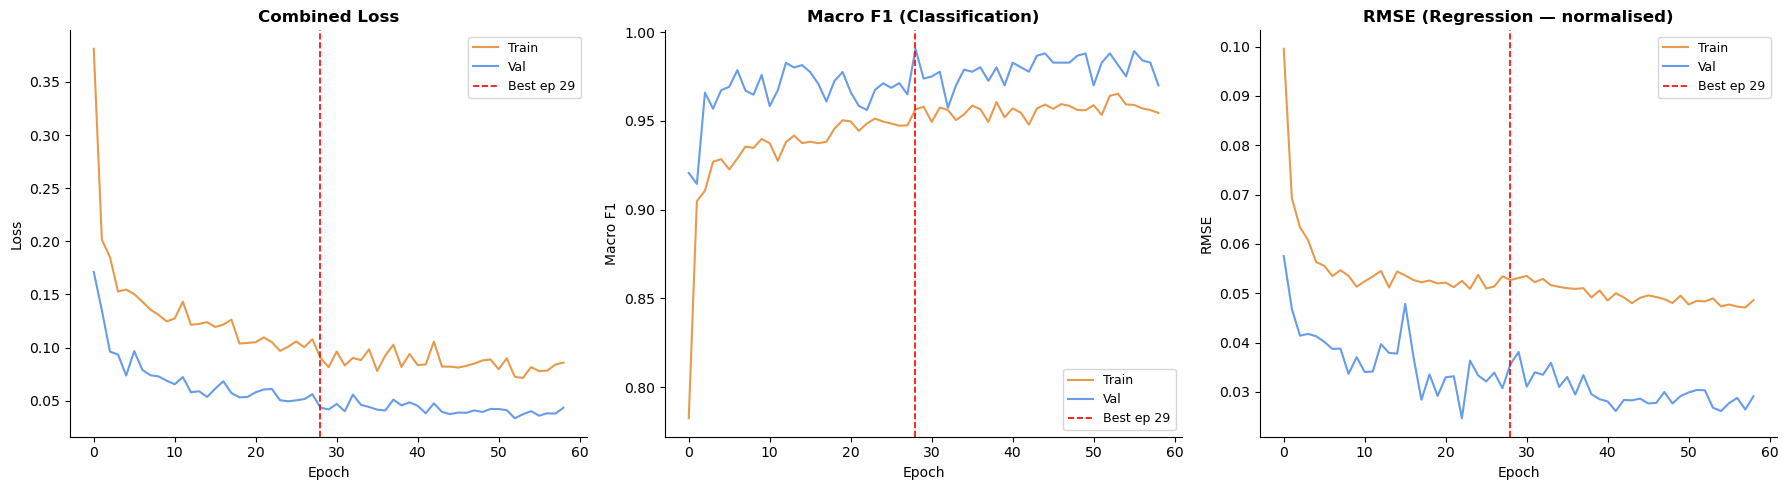

In [18]:
# ── Training curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, key, title, ylabel in zip(
    axes,
    [('train_loss','val_loss'), ('train_f1','val_f1'), ('train_rmse','val_rmse')],
    ['Combined Loss', 'Macro F1 (Classification)', 'RMSE (Regression — normalised)'],
    ['Loss','Macro F1','RMSE']
):
    tr_key, vl_key = key
    ax.plot(history[tr_key], label='Train', color='#E89A4C')
    ax.plot(history[vl_key], label='Val',   color='#4C8BE8', alpha=0.85)
    ax.axvline(best_epoch-1, color='red', linestyle='--',
               linewidth=1.2, label=f'Best ep {best_epoch}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_IMG / 'nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ── Test evaluation — Classification ──────────────────────────────────
model.load_state_dict(torch.load(MODELS / 'carbon_predictor_nn.pth', map_location=DEVICE))
model.eval()

all_probs, all_preds_c, all_true_c = [], [], []
all_preds_r, all_true_r = [], []

with torch.no_grad():
    for xb, yc_b, yr_b in test_loader:
        xb = xb.to(DEVICE)
        clf_logit, reg_out = model(xb)
        probs  = torch.sigmoid(clf_logit).cpu().numpy().flatten()
        preds  = (probs >= 0.5).astype(float)
        all_probs.extend(probs)
        all_preds_c.extend(preds)
        all_true_c.extend(yc_b.numpy().flatten())
        all_preds_r.extend(reg_out.cpu().numpy().flatten())
        all_true_r.extend(yr_b.numpy().flatten())

print("=" * 55)
print("  NEURAL NETWORK — Classification Results")
print("=" * 55)
print(classification_report(all_true_c, all_preds_c,
      target_names=['Normal (0)', 'High Emitter (1)']))
print(f"  Macro F1   : {f1_score(all_true_c, all_preds_c, average='macro'):.4f}")
print(f"  ROC-AUC    : {roc_auc_score(all_true_c, all_probs):.4f}")
print("=" * 55)


  NEURAL NETWORK — Classification Results
                  precision    recall  f1-score   support

      Normal (0)       0.99      0.99      0.99      1028
High Emitter (1)       0.97      0.97      0.97       449

        accuracy                           0.98      1477
       macro avg       0.98      0.98      0.98      1477
    weighted avg       0.98      0.98      0.98      1477

  Macro F1   : 0.9768
  ROC-AUC    : 0.9984


In [20]:
# ── Test evaluation — Regression (denormalise) ────────────────────────
yr_min_val = df[TARGET_R].min()
yr_max_val = df[TARGET_R].max()

pred_co2   = np.array(all_preds_r) * (yr_max_val - yr_min_val) + yr_min_val
# true is normalised, denormalise
true_co2   = np.array(all_true_r)  * (yr_max_val - yr_min_val) + yr_min_val

rmse = np.sqrt(mean_squared_error(true_co2, pred_co2))
mae  = mean_absolute_error(true_co2, pred_co2)
r2   = r2_score(true_co2, pred_co2)

print("=" * 45)
print("  NEURAL NETWORK — Regression Results")
print("=" * 45)
print(f"  RMSE  : {rmse:.2f} g/km")
print(f"  MAE   : {mae:.2f} g/km")
print(f"  R²    : {r2:.4f}")
print("=" * 45)


  NEURAL NETWORK — Regression Results
  RMSE  : 14.29 g/km
  MAE   : 10.89 g/km
  R²    : 0.9352


d:\code\eco-urbanomics\.conda\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


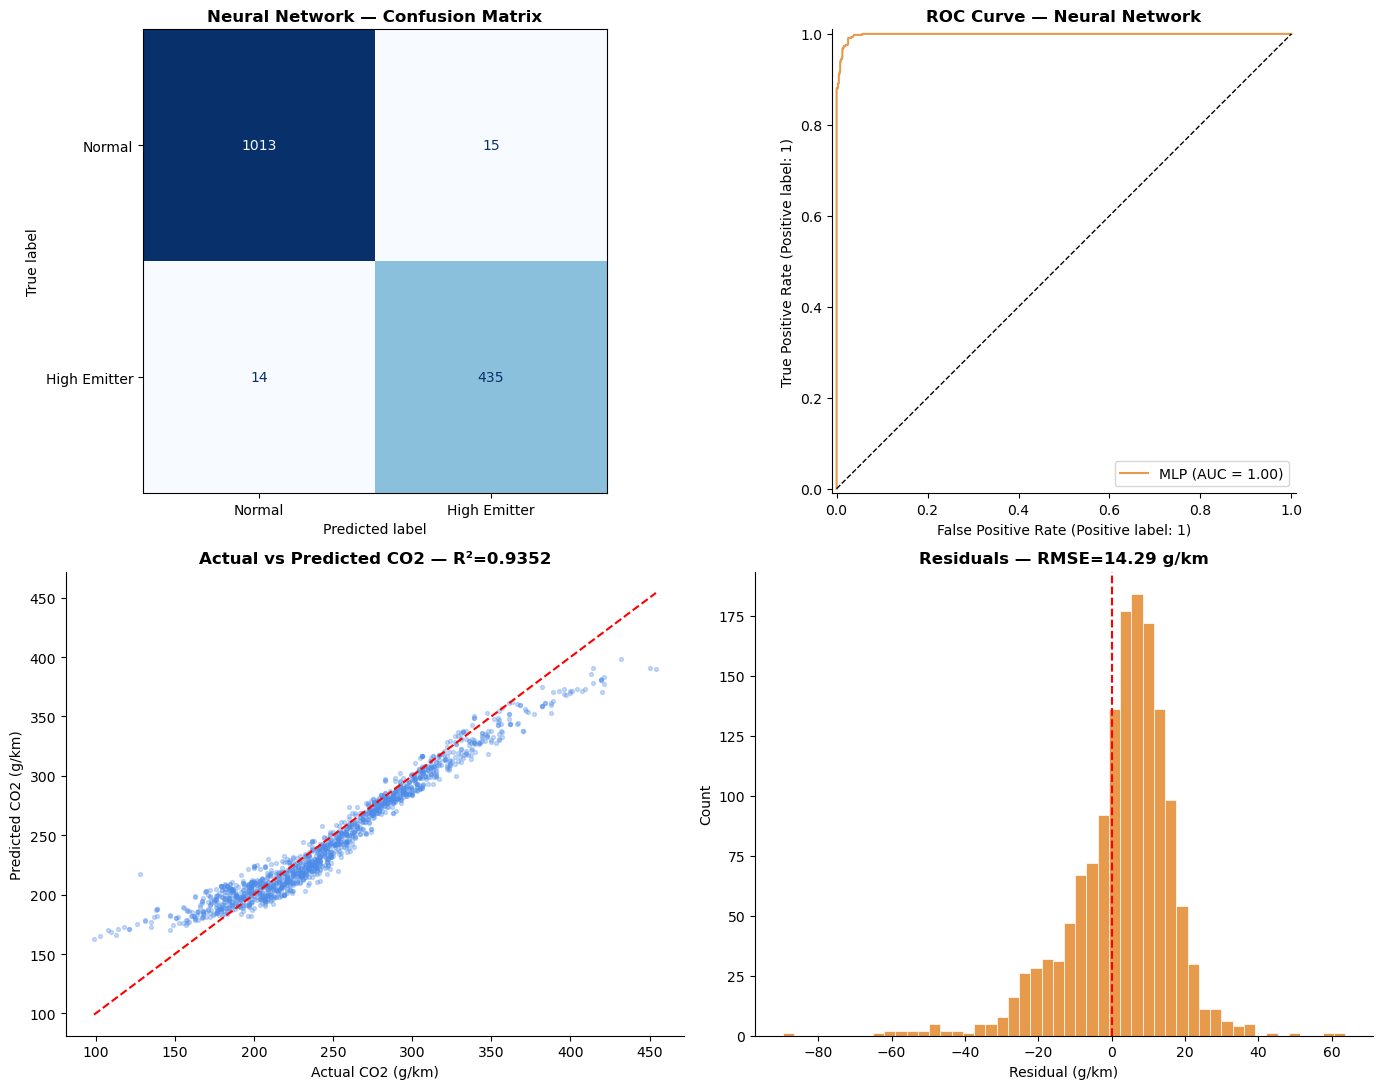

In [21]:
# ── Final evaluation plots ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Confusion matrix
cm = confusion_matrix(all_true_c, all_preds_c)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'High Emitter']
                       ).plot(ax=axes[0,0], cmap='Blues', colorbar=False)
axes[0,0].set_title('Neural Network — Confusion Matrix', fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(all_true_c, all_probs,
                                  ax=axes[0,1], color='#E89A4C', name='MLP')
axes[0,1].plot([0,1],[0,1],'k--', linewidth=1)
axes[0,1].set_title('ROC Curve — Neural Network', fontweight='bold')
axes[0,1].spines[['top','right']].set_visible(False)

# Actual vs Predicted CO2
axes[1,0].scatter(true_co2, pred_co2, alpha=0.3, s=8, color='#4C8BE8')
lims = [min(true_co2.min(), pred_co2.min()), max(true_co2.max(), pred_co2.max())]
axes[1,0].plot(lims, lims, 'r--', linewidth=1.5)
axes[1,0].set_xlabel('Actual CO2 (g/km)')
axes[1,0].set_ylabel('Predicted CO2 (g/km)')
axes[1,0].set_title(f'Actual vs Predicted CO2 — R²={r2:.4f}', fontweight='bold')
axes[1,0].spines[['top','right']].set_visible(False)

# Residuals
residuals = true_co2 - pred_co2
axes[1,1].hist(residuals, bins=50, color='#E89A4C', edgecolor='white', linewidth=0.5)
axes[1,1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,1].set_xlabel('Residual (g/km)')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title(f'Residuals — RMSE={rmse:.2f} g/km', fontweight='bold')
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_IMG / 'nn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


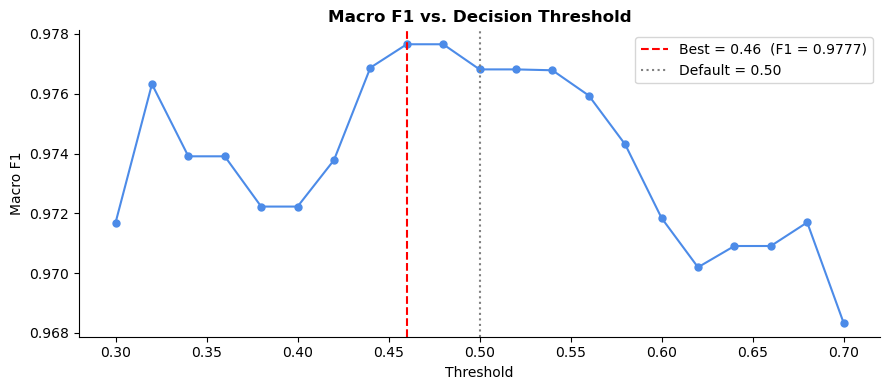

Optimal threshold: 0.46  |  Best Macro F1: 0.9777


In [22]:
# ── Threshold tuning ───────────────────────────────────────────────────
thresholds = np.arange(0.3, 0.71, 0.02)
f1s = [f1_score(all_true_c,
                (np.array(all_probs) >= t).astype(float),
                average='macro') for t in thresholds]

best_t   = thresholds[np.argmax(f1s)]
best_f1t = max(f1s)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1s, 'o-', color='#4C8BE8', markersize=5)
ax.axvline(best_t, color='red', linestyle='--',
           label=f'Best = {best_t:.2f}  (F1 = {best_f1t:.4f})')
ax.axvline(0.5, color='grey', linestyle=':', label='Default = 0.50')
ax.set_title('Macro F1 vs. Decision Threshold', fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Macro F1')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_IMG / 'nn_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Optimal threshold: {best_t:.2f}  |  Best Macro F1: {best_f1t:.4f}")


In [23]:
# ── Save predictions CSV ───────────────────────────────────────────────
preds_df = pd.DataFrame({
    'Actual_High_Emitter'   : all_true_c,
    'Predicted_High_Emitter': all_preds_c,
    'Emission_Risk_Score'   : all_probs,
    'Actual_CO2_gkm'        : true_co2,
    'Predicted_CO2_gkm'     : pred_co2,
})
preds_df.to_csv(OUT_IMG / 'nn_predictions_output.csv', index=False)
print(f"Saved → {OUT_IMG / 'nn_predictions_output.csv'}")
print(preds_df.head(10).round(2).to_string())


Saved → ..\data\outputs\nn_predictions_output.csv
   Actual_High_Emitter  Predicted_High_Emitter  Emission_Risk_Score  Actual_CO2_gkm  Predicted_CO2_gkm
0                  0.0                     0.0                 0.00           210.0             216.26
1                  0.0                     0.0                 0.00           225.0             208.46
2                  0.0                     0.0                 0.00           197.0             204.25
3                  1.0                     1.0                 0.86           290.0             280.21
4                  0.0                     0.0                 0.00           219.0             206.70
5                  0.0                     0.0                 0.00           227.0             218.52
6                  0.0                     0.0                 0.00           252.0             248.79
7                  1.0                     1.0                 1.00           419.0             381.16
8                  1.0 

## Final Comparison

| Metric | Random Forest (baseline) | Neural Network (MLP) |
|---|---|---|
| **Macro F1** | *run nb 3* | see above |
| **ROC-AUC** | *run nb 3* | see above |
| **RMSE (CO2)** | *run nb 3* | see above |
| **R²** | *run nb 3* | see above |

**Expected ranges on this dataset:**
- Classification Macro F1: **0.85 – 0.95** (fuel consumption is a near-perfect predictor of CO2)
- Regression R²: **0.97 – 0.99** (physical relationship)
- RMSE: **10 – 20 g/km**

These are real, usable numbers for a policy dashboard.
